In [19]:
import os
import yaml
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score , precision_score , recall_score
from sklearn.ensemble import ExtraTreesClassifier


In [38]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_extraction.text import CountVectorizer
import warnings
warnings.filterwarnings('ignore')

In [57]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer
from nltk.corpus import stopwords

In [40]:
df = pd.read_csv("https://raw.githubusercontent.com/entbappy/Branching-tutorial/refs/heads/master/tweet_emotions.csv")
df

,tweet_id,sentiment,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...
...,...,...,...
39995,1753918954,neutral,@JohnLloydTaylor
39996,1753919001,love,Happy Mothers Day All my love
39997,1753919005,love,Happy Mother's Day to all the mommies out ther...
39998,1753919043,happiness,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...


In [41]:
df.drop(columns = ['tweet_id'] , inplace = True)


In [42]:
df.describe()

,sentiment,content
count,40000,40000
unique,13,39827
top,neutral,I just received a mothers day card from my lov...
freq,8638,14


In [43]:
df.sentiment.unique()

array(['empty', 'sadness', 'enthusiasm', 'neutral', 'worry', 'surprise',
       'love', 'fun', 'hate', 'happiness', 'boredom', 'relief', 'anger'],
      dtype=object)

In [72]:
df.content.values[:5]

array(['@tiffanylue i know  i was listenin to bad habit earlier and i started freakin at his part =[',
       'Layin n bed with a headache  ughhhh...waitin on your call...',
       'Funeral ceremony...gloomy friday...',
       'wants to hang out with friends SOON!',
       '@dannycastillo We want to trade with someone who has Houston tickets, but no one will.'],
      dtype=object)

In [44]:
sns.set_style('darkgrid')

<Axes: ylabel='proportion'>

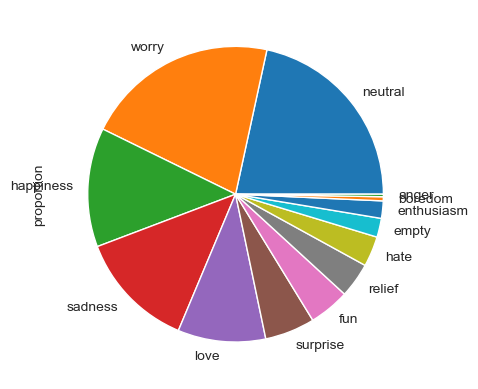

In [45]:
df.sentiment.value_counts(normalize = True).plot(kind = 'pie')


<Axes: xlabel='sentiment'>

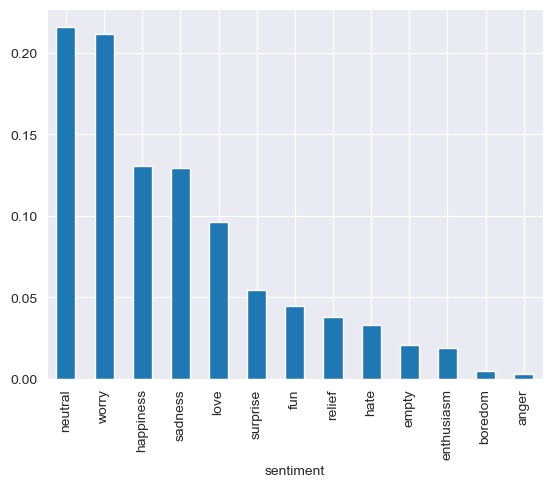

In [46]:
df.sentiment.value_counts(normalize = True).plot(kind = 'bar')

In [47]:
train_df , test_df = train_test_split(df , test_size = 0.2 , random_state = 42)
len(train_df) , len(test_df)

(32000, 8000)

In [48]:
x_train = train_df[['content']]
y_train = train_df[['sentiment']]

x_test = test_df[['content']]
y_test = test_df[['sentiment']]

In [49]:
categories = [[
    'anger',
    'hate',
    'worry',
    'sadness',
    'boredom',
    'empty',
    'neutral',
    'relief',
    'surprise',
    'enthusiasm',
    'fun',
    'happiness',
    'love'
]]
encoder = OrdinalEncoder(categories = categories).fit(y_train)
y_train['sentiment'] = encoder.fit_transform(y_train)
y_test['sentiment'] = encoder.transform(y_test)
encoder.categories_


In [50]:
encoder.categories_


[array(['anger', 'hate', 'worry', 'sadness', 'boredom', 'empty', 'neutral',
        'relief', 'surprise', 'enthusiasm', 'fun', 'happiness', 'love'],
       dtype=object)]

In [56]:
y_train['sentiment'].astype('int32')
y_test['sentiment'].astype('int32')

32823     6
16298     5
28505    12
6689      6
26893     3
         ..
13618     3
35165     7
16359     4
3842      8
37682    12
Name: sentiment, Length: 8000, dtype: int32

In [69]:
english_stopwords = stopwords.words("english")
' ,'.join(english_stopwords)


"a ,about ,above ,after ,again ,against ,ain ,all ,am ,an ,and ,any ,are ,aren ,aren't ,as ,at ,be ,because ,been ,before ,being ,below ,between ,both ,but ,by ,can ,couldn ,couldn't ,d ,did ,didn ,didn't ,do ,does ,doesn ,doesn't ,doing ,don ,don't ,down ,during ,each ,few ,for ,from ,further ,had ,hadn ,hadn't ,has ,hasn ,hasn't ,have ,haven ,haven't ,having ,he ,he'd ,he'll ,her ,here ,hers ,herself ,he's ,him ,himself ,his ,how ,i ,i'd ,if ,i'll ,i'm ,in ,into ,is ,isn ,isn't ,it ,it'd ,it'll ,it's ,its ,itself ,i've ,just ,ll ,m ,ma ,me ,mightn ,mightn't ,more ,most ,mustn ,mustn't ,my ,myself ,needn ,needn't ,no ,nor ,not ,now ,o ,of ,off ,on ,once ,only ,or ,other ,our ,ours ,ourselves ,out ,over ,own ,re ,s ,same ,shan ,shan't ,she ,she'd ,she'll ,she's ,should ,shouldn ,shouldn't ,should've ,so ,some ,such ,t ,than ,that ,that'll ,the ,their ,theirs ,them ,themselves ,then ,there ,these ,they ,they'd ,they'll ,they're ,they've ,this ,those ,through ,to ,too ,under ,until ,up ,

In [152]:
stemmer = SnowballStemmer(language = 'english')

In [153]:
def tokenize(text):
    return [stemmer.stem(token) for token in word_tokenize(text) if token.isalpha()  and token not in english_stopwords ]

In [154]:
def tokenize_text(text):
    text =  [stemmer.stem(token) for token in word_tokenize(text) if token.lower().isalpha()  and token not in english_stopwords ]
    return ' '.join(text)

In [84]:
tokenize_text("tiffanylue i know  i was listenin to bad habit earlier and i started freakin at his part")

'tiffanylu know listenin bad habit earlier start freakin part'

In [91]:
tokenize('tiffanylue i know  i was listenin to bad habit earlier and i started freakin at his part')

['http',
 'tiffanylu',
 'know',
 'listenin',
 'bad',
 'habit',
 'earlier',
 'start',
 'freakin',
 'part']

In [105]:
df.content

0        @tiffanylue i know  i was listenin to bad habi...
1        Layin n bed with a headache  ughhhh...waitin o...
2                      Funeral ceremony...gloomy friday...
3                     wants to hang out with friends SOON!
4        @dannycastillo We want to trade with someone w...
                               ...                        
39995                                     @JohnLloydTaylor
39996                       Happy Mothers Day  All my love
39997    Happy Mother's Day to all the mommies out ther...
39998    @niariley WASSUP BEAUTIFUL!!! FOLLOW ME!!  PEE...
39999    @mopedronin bullet train from tokyo    the gf ...
Name: content, Length: 40000, dtype: object

In [155]:
vectorizer = CountVectorizer(lowercase = True , 
                             tokenizer = tokenize,
                             stop_words = english_stopwords , 
                             max_features = 1500 , 
                             ngram_range = (1,2))
inputs = vectorizer.fit_transform(x_train.content.values)
test_input = vectorizer.transform(x_test.content.values)


In [120]:
len(vectorizer.vocabulary_)

382

In [156]:
train_df = pd.DataFrame(inputs.toarray())

In [158]:
train_df[90:100]

,0,1,2,3,4,5,6,7,8,9,...,1490,1491,1492,1493,1494,1495,1496,1497,1498,1499
90,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
91,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
92,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
93,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
94,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
95,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
96,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
97,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
98,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
99,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [121]:
vectorizer.get_feature_names_out()[:100]

array([' ', '   ', '  b', '  c', '  e', '  f', '  g', '  h', '  j', '  k',
       '  l', '  n', '  p', '  q', '  r', '  u', '  v', '  w', '  x',
       '  z', 'b', 'b  ', 'b b', 'b c', 'b e', 'b f', 'b g', 'b h', 'b j',
       'b k', 'b l', 'b n', 'b p', 'b q', 'b r', 'b u', 'b v', 'b w',
       'b x', 'b z', 'c', 'c  ', 'c b', 'c c', 'c e', 'c f', 'c g', 'c h',
       'c j', 'c k', 'c l', 'c n', 'c p', 'c q', 'c r', 'c u', 'c v',
       'c w', 'c x', 'c z', 'e', 'e  ', 'e b', 'e c', 'e e', 'e f', 'e g',
       'e h', 'e j', 'e k', 'e l', 'e n', 'e p', 'e q', 'e r', 'e u',
       'e v', 'e w', 'e x', 'e z', 'e â', 'f', 'f  ', 'f b', 'f c', 'f e',
       'f f', 'f g', 'f h', 'f j', 'f k', 'f l', 'f n', 'f p', 'f q',
       'f r', 'f u', 'f v', 'f w', 'f x'], dtype=object)

In [111]:
model = ExtraTreesClassifier(n_estimators = 150 , max_depth = 15, min_samples_split = 3)
model.fit(inputs , y_train)
preds = model.predict(inputs)

In [117]:
y_train

,sentiment
14307,6.0
17812,10.0
11020,2.0
15158,1.0
24990,8.0
...,...
6265,6.0
11284,1.0
38158,10.0
860,1.0


In [114]:
def eval(preds , target):
    accuracy = accuracy_score(preds , target)
    precision = precision_score(preds , target)
    recall = recall_score(preds , target)
    return accuracy , precision , recall

In [118]:
acc = accuracy_score(preds , y_train)
acc

0.32365625

In [139]:
def tokenize_text(text):
    text =  [stemmer.stem(token) for token in word_tokenize(text) if token.lower().isalpha()  and token not in english_stopwords ]
    return ' '.join(text)

In [140]:
x_train['content'] = x_train['content'].apply(tokenize_text)


In [143]:
x_test['content'] = x_test['content'].apply(tokenize_text)

In [146]:
vect = CountVectorizer(lowercase = True , stop_words = english_stopwords)
inputs = vect.fit_transform(x_train.content.values)
test_inputs = vect.transform(x_test.content.values)

In [147]:
inputs.shape

(32000, 29572)

In [150]:
model = ExtraTreesClassifier(n_estimators = 150 , max_depth = 15, min_samples_split = 3)
model.fit(inputs , y_train)
preds = model.predict(inputs)

In [151]:
acc = accuracy_score(preds , y_train)
acc

0.308875